# Zomato Delhi — EDA (Case study: Khuyến mãi)

Phân tích khám phá dữ liệu, trả lời Business Question #7–9 về khuyến mãi. Cần chạy 02a_zomato_cleaning trước.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
pd.set_option('display.max_columns', 50)

## ĐƯỜNG DẪN

In [2]:
try:
    BASE_DIR = Path(__file__).resolve().parent.parent
except NameError:
    BASE_DIR = Path.cwd().resolve().parent
CLEAN_PATH = BASE_DIR / 'data' / 'clean' / 'zomato_clean.csv'
CHARTS_DIR = BASE_DIR / 'outputs' / 'charts'
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

## 1. ĐỌC DỮ LIỆU ĐÃ LÀM SẠCH

In [3]:
# Cần chạy 02a_zomato_cleaning trước để có file này
df = pd.read_csv(CLEAN_PATH, parse_dates=['Order Placed At'])
df['has_discount'] = df['has_discount'].astype(bool)  # CSV lưu True/False dạng chữ, ép lại kiểu bool
print("Shape dữ liệu đã làm sạch:", df.shape)

# Chỉ tính Revenue/AOV trên đơn thành công (Delivered)
df_delivered = df[df['Order Status'] == 'Delivered'].copy()
print(f"Số đơn 'Delivered' dùng để tính Revenue/AOV: {len(df_delivered)} / {len(df)}")

Shape dữ liệu đã làm sạch: (21321, 26)
Số đơn 'Delivered' dùng để tính Revenue/AOV: 21131 / 21321


## Phân phối giá trị đơn và kiểm tra outlier

Xem phân phối của `Total` (doanh thu proxy, đơn `Delivered`) trước khi so sánh AOV. Outlier theo quy tắc IQR chỉ để quan sát, **không xóa**.

=== Phân phối giá trị đơn (Total) - Zomato, đơn Delivered ===
count    21131.0
mean       682.6
std        463.6
min         52.5
25%        388.5
50%        597.4
75%        837.9
max      12663.0

Trung bình = 683 | trung vị = 597 | skewness = 4.49 | outlier IQR = 906 (4.3%)

Theo có/không khuyến mãi:
              so_don  trung_binh  trung_vi
has_discount                              
False           8217       710.0     629.0
True           12914       665.1     566.1


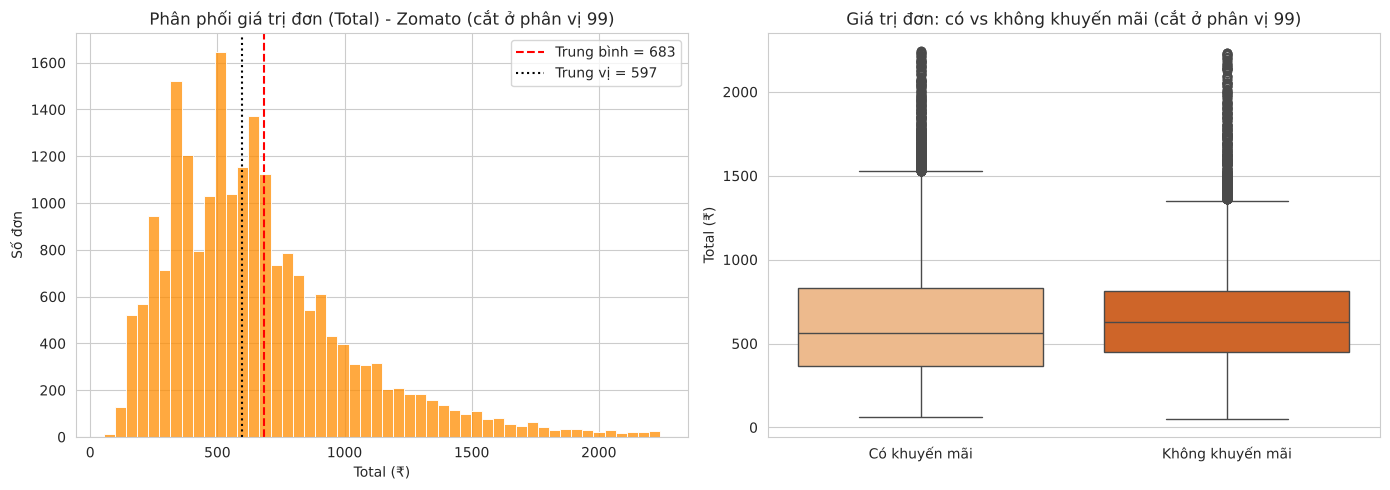

In [4]:
def iqr_outliers(s):
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()

total = df_delivered['Total']
print("=== Phân phối giá trị đơn (Total) - Zomato, đơn Delivered ===")
print(total.describe().round(1).to_string())
print(f"\nTrung bình = {total.mean():,.0f} | trung vị = {total.median():,.0f} | skewness = {total.skew():.2f} | "
      f"outlier IQR = {iqr_outliers(total)} ({iqr_outliers(total)/len(total)*100:.1f}%)")
print("\nTheo có/không khuyến mãi:")
print(df_delivered.groupby('has_discount')['Total'].agg(so_don='count', trung_binh='mean', trung_vi='median').round(1).to_string())

p99 = total.quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(total[total <= p99], bins=50, color='darkorange', ax=axes[0])
axes[0].axvline(total.mean(), color='red', linestyle='--', label=f'Trung bình = {total.mean():,.0f}')
axes[0].axvline(total.median(), color='black', linestyle=':', label=f'Trung vị = {total.median():,.0f}')
axes[0].set_title('Phân phối giá trị đơn (Total) - Zomato (cắt ở phân vị 99)')
axes[0].set_xlabel('Total (₹)')
axes[0].set_ylabel('Số đơn')
axes[0].legend()

plot_df = df_delivered.assign(nhom=df_delivered['has_discount'].map({True: 'Có khuyến mãi', False: 'Không khuyến mãi'}))
sns.boxplot(data=plot_df[plot_df['Total'] <= p99], x='nhom', y='Total', hue='nhom', palette='Oranges', legend=False, ax=axes[1])
axes[1].set_title('Giá trị đơn: có vs không khuyến mãi (cắt ở phân vị 99)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Total (₹)')

plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_eda_revenue_distribution_zomato.png', dpi=120)
plt.show()
plt.close()

**Cách đọc và nhận xét (từ output ở trên):**
- Phân phối `Total` **lệch phải** (skewness ≈ 4,49): trung bình ₹683 cao hơn trung vị ₹597. Có 906 đơn (≈ 4,3%) bị đánh dấu outlier theo IQR, giữ nguyên trong phân tích.
- Biểu đồ cắt ở phân vị 99 cho dễ nhìn; thống kê ở trên vẫn tính trên toàn bộ đơn.
- Đơn có khuyến mãi có cả trung bình (₹665 so với ₹710) lẫn trung vị (₹566 so với ₹629) thấp hơn đơn không có khuyến mãi; hướng chênh lệch nhất quán. `Total` là số sau giảm giá nên chênh lệch này một phần mang tính cơ học, không chứng minh nhân quả.

## Q7: SỐ LƯỢNG ĐƠN CÓ / KHÔNG KHUYẾN MÃI KHÁC NHAU NHƯ THẾ NÀO?


=== Số lượng đơn theo có/không khuyến mãi (đơn Delivered) ===
has_discount
False     8217
True     12914
dtype: int64


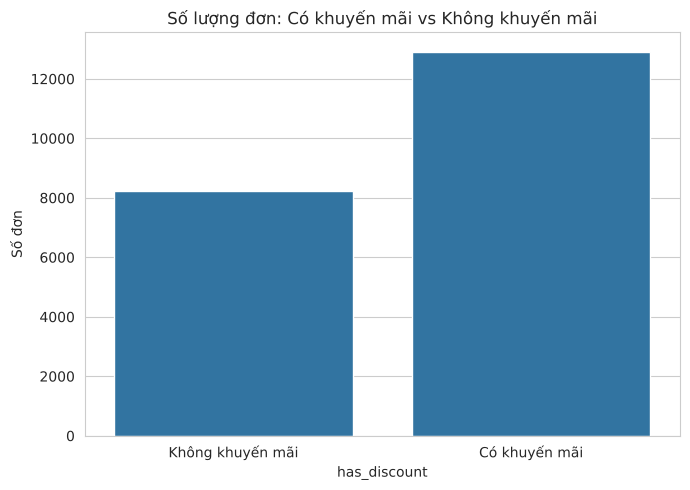

In [5]:
orders_by_discount = df_delivered.groupby('has_discount').size()
print("\n=== Số lượng đơn theo có/không khuyến mãi (đơn Delivered) ===")
print(orders_by_discount)

plt.figure(figsize=(7, 5))
sns.barplot(x=orders_by_discount.index.map({True: 'Có khuyến mãi', False: 'Không khuyến mãi'}),
            y=orders_by_discount.values)
plt.title('Số lượng đơn: Có khuyến mãi vs Không khuyến mãi')
plt.ylabel('Số đơn')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_orders_by_discount.png', dpi=120)
plt.show()
plt.close()

> **Lưu ý diễn giải:** code ở trên chỉ **đếm** số đơn theo có/không khuyến mãi trong cùng một giai đoạn. Dữ liệu không có nhóm đối chứng hay biến động theo thời gian, nên kết quả **chưa đủ để kết luận khuyến mãi làm tăng số đơn**; đây chỉ là mô tả mối liên hệ.

## Q8: AOV CỦA ĐƠN CÓ KHUYẾN MÃI CÓ KHÁC ĐƠN KHÔNG KHUYẾN MÃI KHÔNG?


=== AOV theo có/không khuyến mãi (đơn Delivered) ===
has_discount
False    710.017024
True     665.105302
Name: Total, dtype: float64

Tương quan Tổng khuyến mãi vs Bill subtotal: 0.504


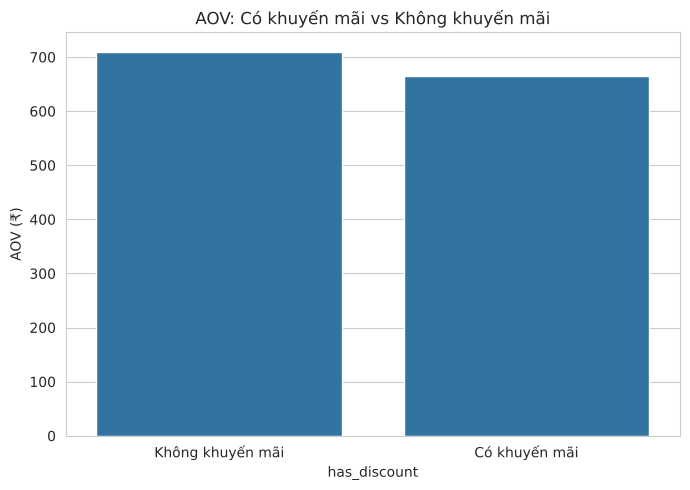

In [6]:
aov_by_discount = df_delivered.groupby('has_discount')['Total'].mean()
print("\n=== AOV theo có/không khuyến mãi (đơn Delivered) ===")
print(aov_by_discount)

corr_discount_bill = df_delivered['total_discount'].corr(df_delivered['Bill subtotal'])
print(f"\nTương quan Tổng khuyến mãi vs Bill subtotal: {corr_discount_bill:.3f}")

plt.figure(figsize=(7, 5))
sns.barplot(x=aov_by_discount.index.map({True: 'Có khuyến mãi', False: 'Không khuyến mãi'}),
            y=aov_by_discount.values)
plt.title('AOV: Có khuyến mãi vs Không khuyến mãi')
plt.ylabel('AOV (₹)')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_aov_by_discount.png', dpi=120)
plt.show()
plt.close()

> **Lưu ý diễn giải:** chênh lệch AOV giữa đơn có và không có khuyến mãi là mối liên hệ, không phải quan hệ nhân quả. `Total` là số **sau giảm giá**, nên AOV của đơn có khuyến mãi thấp hơn một phần do cơ chế tính toán; tương quan giữa tiền giảm và hóa đơn gốc cũng một phần mang tính cơ học.

## Q9: ĐƠN HỦY/TỪ CHỐI CÓ LIÊN QUAN ĐẾN KPT DURATION KHÔNG?


=== Thời gian chuẩn bị (KPT) trung bình theo Trạng thái đơn ===
Order Status
Picked up           19.590000
Delivered           17.339428
Returned            16.673600
Rejected            15.516721
Return cancelled    12.366667
Timed out                 NaN
Name: KPT duration (minutes), dtype: float64


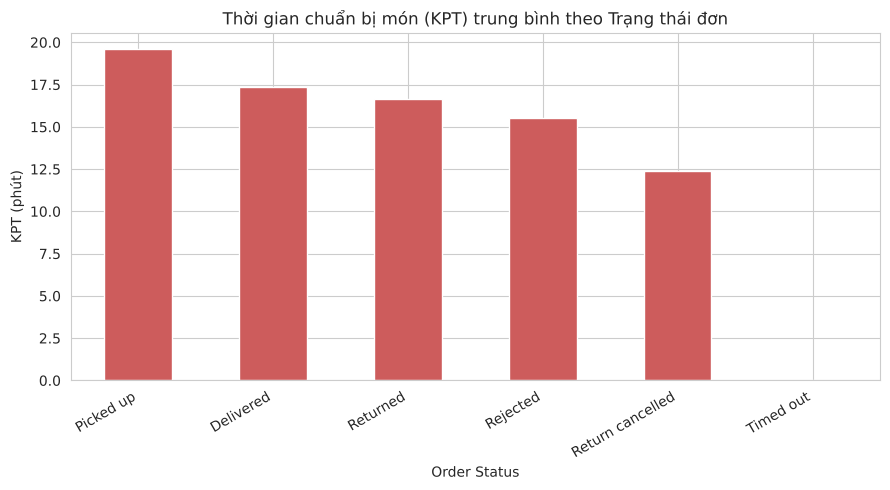


=== Phân bố Order Status (%) ===
Order Status
Delivered           99.108860
Rejected             0.741053
Returned             0.117255
Return cancelled     0.014071
Picked up            0.014071
Timed out            0.004690
Name: proportion, dtype: float64

=== HOÀN TẤT EDA ZOMATO ===
Các biểu đồ đã lưu vào outputs/charts/


In [7]:
status_kpt = df.groupby('Order Status')['KPT duration (minutes)'].mean().sort_values(ascending=False)
print("\n=== Thời gian chuẩn bị (KPT) trung bình theo Trạng thái đơn ===")
print(status_kpt)

plt.figure(figsize=(9, 5))
status_kpt.plot(kind='bar', color='indianred')
plt.title('Thời gian chuẩn bị món (KPT) trung bình theo Trạng thái đơn')
plt.ylabel('KPT (phút)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(CHARTS_DIR / 'chart_kpt_by_status.png', dpi=120)
plt.show()
plt.close()

order_status_dist = df['Order Status'].value_counts(normalize=True) * 100
print("\n=== Phân bố Order Status (%) ===")
print(order_status_dist)

print("\n=== HOÀN TẤT EDA ZOMATO ===")
print("Các biểu đồ đã lưu vào outputs/charts/")